# 이커머스 유저 행동 분석 기반 구매 전환율 최적화 및 A/B 테스트 설계

**E-commerce Conversion Optimization & A/B Testing**

## 01. Business Understanding

### 1. 프로젝트 배경

본 프로젝트는 이커머스 플랫폼의 Product Data Scientist가 구매 전환율 개선을 위한 분석 업무를 수행하는 상황을 가정한다.

고객은 상품 조회(View), 장바구니 추가(Cart), 구매(Purchase) 등의 행동을 수행하며, 각 행동 단계에서 이탈할 수 있다.

기업은 고객의 구매 여정을 분석해 주요 이탈 구간을 파악하고, 전환율을 개선할 수 있는 제품 및 서비스 개선안을 검토하고자 한다.

### 2. 비즈니스 목표

사용자 행동 로그를 기반으로 구매 전환 과정의 병목 구간을 식별하고, 개선 가설을 수립한 뒤 해당 가설의 효과를 평가하기 위한 A/B 테스트 프레임워크를 설계한다.

**핵심 분석 질문**

1. 사용자는 상품 조회부터 구매까지 어떤 행동 패턴을 보이는가?
2. 구매 전환 과정에서 어떤 단계의 이탈이 가장 두드러지는가?
3. 사용자 및 상품 특성에 따라 전환율은 어떻게 다른가?
4. 어떤 제품 개선 가설을 우선적으로 검증해야 하는가?
5. 개선 효과를 검증하려면 어떤 실험 설계와 통계적 기준이 필요한가?
6. 실험 결과를 바탕으로 어떤 비즈니스 의사결정을 내려야 하는가?

### 3. 분석 접근 방식

- 데이터 품질 검증 및 전처리
- 사용자 행동 탐색 분석(EDA)
- 구매 전환 퍼널(Funnel) 분석
- 전환율 개선 가설 도출
- A/B 테스트 설계
- Statistical Power 및 Sample Size 분석
- A/B 테스트 시뮬레이션
- 가설 검정 및 신뢰구간 분석
- 코호트 기반 리텐션 분석
- 비즈니스 의사결정 제안

### 4. 데이터 및 분석 범위

**데이터 출처:** Kaggle — E-commerce Behavior Data from Multi-Category Store

**프로젝트 유형:** 공개 데이터 기반 개인 포트폴리오 프로젝트

본 데이터는 실제 무작위 실험 결과가 아닌 관찰 데이터(Observational Data)이므로, 구매 행동 분석과 실험 시뮬레이션을 명확히 구분한다.

실험 시뮬레이션 결과는 분석 방법론을 검증하기 위한 가상 결과이며, 실제 제품 개선 효과에 대한 인과적 증거로 해석하지 않는다.

## 02. KPI 정의 (Key Performance Indicators)

### 1. Primary KPI: 구매 전환율 (Purchase Conversion Rate)

본 프로젝트의 핵심 목표는 이커머스 플랫폼의 구매 전환율을 개선하는 것이다.

구매 전환율은 일정 기간 동안 구매를 완료한 사용자 수를 분석 대상 사용자 수로 나눈 비율이다.

**구매 전환율(CVR)**

구매 전환율(%) = (구매 완료 사용자 수 / 분석 대상 사용자 수) × 100

본 프로젝트에서는 탐색 분석과 A/B 테스트 시뮬레이션의 대상 사용자 및 관찰 기간을 명확하게 정의한다.

### 2. Secondary KPIs: 보조 성과 지표

| KPI | 정의 | 분석 목적 |
|---|---|---|
| View-to-Cart Rate | 상품 조회 사용자 중 장바구니에 상품을 추가한 사용자 비율 | 상품 관심에서 구매 의도로의 전환 평가 |
| Cart-to-Purchase Rate | 장바구니 사용자 중 구매를 완료한 사용자 비율 | 구매 직전 이탈 분석 |
| Revenue per User (RPU) | 전체 구매 매출 / 분석 대상 사용자 수 | 사용자당 매출 성과 평가 |
| Average Order Value (AOV) | 총매출 / 주문 건수 | 주문당 평균 매출 평가 |

### 3. Guardrail Metrics: 부작용 감시 지표

구매 전환율이 개선되더라도 사용자 경험이나 다른 비즈니스 성과가 악화될 수 있으므로 추가 지표를 확인한다.

- 사용자 이탈 관련 지표
- 페이지 성능 및 오류율
- 구매 취소 및 환불률

단, 현재 데이터에서 측정할 수 없는 지표는 실제 기업 환경에서 추가 수집이 필요한 항목으로 구분한다.

### 4. Retention KPI: 재구매율

첫 구매를 완료한 사용자가 일정 기간 이내 추가 구매를 수행하는 비율을 분석한다.

이를 통해 단기적인 구매 전환뿐 아니라 장기적인 고객 유지 가능성도 검토한다.

### 5. KPI 활용 전략

본 프로젝트에서는 구매 전환율을 핵심 지표로 설정하고, 퍼널 분석을 통해 전환 과정의 주요 이탈 구간을 식별한다.

이후 해당 구간에 대한 개선 가설을 수립하고 A/B 테스트를 설계한다.

실험 분석에서는 구매 전환율의 변화뿐 아니라 효과 크기, 신뢰구간, 통계적 유의성 및 비즈니스적 의미를 종합적으로 평가한다.

## 0.3 분석 목적 및 초기 가설

### 분석 목적

본 프로젝트는 이커머스 사용자 행동 로그를 분석하여 구매 전환 과정의 주요 병목 구간을 파악하고, 데이터 기반 제품 개선 가설과 실험 설계를 도출하는 것을 목적으로 한다.

### 초기 가설 후보

**가설 1. 상품 조회 이후 장바구니 추가 단계에서 개선 기회가 존재할 수 있다.**

- 검증 방법: View-to-Cart 전환율 및 사용자 행동 패턴 분석
- 주요 지표: View-to-Cart Rate

**가설 2. 사용자 및 상품 카테고리에 따라 구매 전환율의 차이가 존재할 수 있다.**

- 검증 방법: 사용자 행동 및 상품 카테고리별 전환율 비교
- 주요 지표: Purchase Conversion Rate

**가설 3. 상품 상세 페이지의 정보 제공 방식을 개선하면 구매 전환율이 증가할 수 있다.**

- 검증 방법: A/B 테스트 설계 및 실험 시뮬레이션
- 주요 지표: Purchase Conversion Rate
- 보조 지표: View-to-Cart Rate

### 분석 전략

초기 가설은 확정된 사실이 아닌 분석 방향을 설정하기 위한 후보이다.

EDA 및 퍼널 분석 결과를 바탕으로 실제 개선이 필요한 구간을 선정하고, A/B 테스트를 통해 검증할 제품 개선 가설을 구체화한다.

공개 행동 로그에는 실제 제품 개선 실험이 포함되어 있지 않으므로, 실험 효과에 대한 분석은 별도의 시뮬레이션으로 진행한다.

In [5]:
import os
import pandas as pd
import numpy as np
import kagglehub

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Kaggle 데이터 다운로드
path = kagglehub.dataset_download(
    "mkechinov/ecommerce-behavior-data-from-multi-category-store"
)

print("Dataset path:", path)
print("Files:", os.listdir(path))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 4.29G/4.29G [02:26<00:00, 31.5MB/s]

Extracting files...


Dataset path: /Users/jisoopak/.cache/kagglehub/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/versions/8
Files: ['2019-Nov.csv', '2019-Oct.csv']


In [6]:
file_list = sorted([
    file for file in os.listdir(path)
    if file.endswith(".csv")
])

for file in file_list:
    file_path = os.path.join(path, file)
    size_mb = os.path.getsize(file_path) / (1024 ** 2)

    print(f"{file} | {size_mb:.2f} MB")

2019-Nov.csv | 8589.52 MB
2019-Oct.csv | 5406.01 MB


In [7]:
csv_file_path = os.path.join(path, file_list[0])

preview = pd.read_csv(csv_file_path, nrows=5)

display(preview)
print(preview.dtypes)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object


In [8]:
df = pd.read_csv(
    csv_file_path,
    skiprows=lambda i: i > 0 and np.random.random() > 0.03
)

In [9]:
user_ids = pd.read_csv(
    csv_file_path,
    usecols=["user_id"]
)

unique_users = user_ids["user_id"].dropna().unique()

print(f"전체 고유 사용자 수: {len(unique_users):,}")

전체 고유 사용자 수: 3,696,117


In [10]:
rng = np.random.default_rng(RANDOM_STATE)

sample_rate = 0.10

sample_size = int(len(unique_users) * sample_rate)

sample_users = rng.choice(
    unique_users,
    size=sample_size,
    replace=False
)

sample_users_set = set(sample_users)

print(f"샘플 사용자 수: {len(sample_users):,}")

샘플 사용자 수: 369,611


In [11]:
chunks = []

chunk_size = 1_000_000

for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
    
    filtered_chunk = chunk[
        chunk["user_id"].isin(sample_users_set)
    ]
    
    chunks.append(filtered_chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"최종 샘플 로그 수: {len(df):,}")
print(f"고유 사용자 수: {df['user_id'].nunique():,}")

최종 샘플 로그 수: 6,770,017
고유 사용자 수: 369,611


In [12]:
print("데이터 크기:", df.shape)

print("\n컬럼:")
print(df.columns.tolist())

print("\n데이터 타입:")
print(df.dtypes)

print("\n기본 데이터:")
display(df.head())

데이터 크기: (6770017, 9)

컬럼:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

데이터 타입:
event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object

기본 데이터:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
1,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
2,2019-11-01 00:00:03 UTC,view,17200570,2053013559792632471,furniture.living_room.sofa,NaN,437.33,518780843,aa806835-b14c-45af-9538-cd4d1849be3e
3,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
4,2019-11-01 00:00:11 UTC,view,41100055,2090228413959766319,NaN,NaN,38.07,562234311,4cbd502f-b1df-4bcf-a1cb-78bb18c37e70


In [13]:
df["event_time"] = pd.to_datetime(
    df["event_time"],
    utc=True
).dt.tz_convert(None)

print("시작 날짜:", df["event_time"].min())
print("종료 날짜:", df["event_time"].max())
print("분석 기간:", df["event_time"].max() - df["event_time"].min())

시작 날짜: 2019-11-01 00:00:01
종료 날짜: 2019-11-30 23:59:51
분석 기간: 29 days 23:59:50


In [15]:
event_counts = (
    df["event_type"]
    .value_counts()
    .to_frame("count")
)

event_counts["ratio"] = (
    event_counts["count"] / len(df)
)

display(event_counts)

,count,ratio
event_type,,
view,6374973,0.941648
cart,302603,0.044698
purchase,92441,0.013654


In [16]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean()
})

missing = missing.sort_values(
    "missing_rate",
    ascending=False
)

display(missing)

,missing_count,missing_rate
category_code,2207562,3.260792e-01
brand,927574,1.370121e-01
user_session,2,2.954202e-07
event_time,0,0.000000e+00
event_type,0,0.000000e+00
product_id,0,0.000000e+00
category_id,0,0.000000e+00
price,0,0.000000e+00
user_id,0,0.000000e+00


In [17]:
duplicate_count = df.duplicated().sum()

print(f"완전 중복 행 수: {duplicate_count:,}")
print(f"중복 비율: {duplicate_count / len(df):.4%}")

완전 중복 행 수: 9,309
중복 비율: 0.1375%


In [18]:
summary = {
    "총 이벤트 수": len(df),
    "고유 사용자 수": df["user_id"].nunique(),
    "고유 세션 수": df["user_session"].nunique(),
    "고유 상품 수": df["product_id"].nunique(),
    "고유 카테고리 수": df["category_id"].nunique()
}

for key, value in summary.items():
    print(f"{key}: {value:,}")

총 이벤트 수: 6,770,017
고유 사용자 수: 369,611
고유 세션 수: 1,377,746
고유 상품 수: 140,703
고유 카테고리 수: 673


## 02. Data Understanding & Quality Check

본 단계에서는 본격적인 분석에 앞서 데이터의 구조, 분석 기간, 사용자 규모, 이벤트 구성 및 데이터 품질을 확인한다.

### 분석 목적

- 데이터가 어떤 단위로 기록되어 있는지 파악한다.
- 분석 가능한 사용자 및 이벤트 규모를 확인한다.
- 결측치와 중복 데이터 등 데이터 품질 문제를 확인한다.
- 구매 전환 및 리텐션 분석에 적합한 데이터 구조인지 검증한다.

### Sampling Strategy

원본 데이터는 대규모 이벤트 로그이므로 분석 환경의 메모리 제약을 고려해 일부 사용자를 무작위 추출한다.

단순 이벤트 행 단위 샘플링은 한 사용자의 행동 이력을 일부 누락시켜 구매 퍼널 및 리텐션 분석을 왜곡할 수 있다.

따라서 본 프로젝트에서는 **User-level Random Sampling**을 적용하여 선택된 사용자의 전체 행동 로그를 보존한다.

### 주요 품질 점검 항목

- 분석 기간
- 이벤트 종류 및 분포
- 고유 사용자 수
- 고유 세션 수
- 고유 상품 수
- 결측치 비율
- 중복 데이터
- 주요 변수의 데이터 타입

이 과정을 통해 후속 Funnel Analysis 및 Retention Analysis에 사용할 데이터의 신뢰성과 분석 범위를 정의한다.

## 03. Data Cleaning & Feature Engineering

본 단계에서는 사용자 행동 로그를 구매 전환 및 리텐션 분석에 적합한 형태로 정제한다.

### 주요 전처리 목표

- 분석에 영향을 줄 수 있는 중복 데이터를 확인하고 처리한다.
- 카테고리 및 브랜드 결측치를 보존 가능한 형태로 정리한다.
- 시간 변수를 분석 가능한 형식으로 변환한다.
- 사용자 행동 분석에 필요한 날짜, 시간, 요일 파생변수를 생성한다.
- 가격 데이터의 이상값을 점검한다.
- 이후 Funnel 및 Retention 분석을 위한 사용자 단위 행동 정보를 구축한다.

전처리 과정에서는 원본 행동 로그를 최대한 보존하되, 각 처리 과정이 분석 결과에 미칠 수 있는 영향을 함께 고려한다.

In [19]:
df_clean = df.copy()

print("원본 데이터:", df.shape)
print("분석 데이터:", df_clean.shape)

원본 데이터: (6770017, 9)
분석 데이터: (6770017, 9)


In [20]:
duplicate_count = df_clean.duplicated().sum()

print(f"중복 제거 전: {len(df_clean):,}")
print(f"완전 중복 행: {duplicate_count:,}")

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"중복 제거 후: {len(df_clean):,}")

중복 제거 전: 6,770,017
완전 중복 행: 9,309
중복 제거 후: 6,760,708


In [21]:
df_clean["category_code"] = (
    df_clean["category_code"]
    .fillna("unknown")
)

df_clean["brand"] = (
    df_clean["brand"]
    .fillna("unknown")
)

print("category_code missing:",
      df_clean["category_code"].isna().sum())

print("brand missing:",
      df_clean["brand"].isna().sum())

category_code missing: 0
brand missing: 0


In [22]:
df_clean["event_time"] = pd.to_datetime(
    df_clean["event_time"],
    utc=True
).dt.tz_convert(None)

print(df_clean["event_time"].dtype)

print(
    df_clean["event_time"].min(),
    "~",
    df_clean["event_time"].max()
)

datetime64[us]
2019-11-01 00:00:01 ~ 2019-11-30 23:59:51


In [23]:
df_clean["event_date"] = (
    df_clean["event_time"].dt.date
)

df_clean["event_hour"] = (
    df_clean["event_time"].dt.hour
)

df_clean["day_of_week"] = (
    df_clean["event_time"].dt.day_name()
)

df_clean["day"] = (
    df_clean["event_time"].dt.day
)

display(
    df_clean[
        [
            "event_time",
            "event_date",
            "event_hour",
            "day_of_week"
        ]
    ].head()
)

,event_time,event_date,event_hour,day_of_week
0,2019-11-01 00:00:01,2019-11-01,0,Friday
1,2019-11-01 00:00:01,2019-11-01,0,Friday
2,2019-11-01 00:00:03,2019-11-01,0,Friday
3,2019-11-01 00:00:08,2019-11-01,0,Friday
4,2019-11-01 00:00:11,2019-11-01,0,Friday


In [24]:
print(df_clean["event_type"].value_counts())

event_type
view        6374846
cart         293422
purchase      92440
Name: count, dtype: int64


In [25]:
display(
    df_clean["price"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99
        ]
    )
)

count    6.760708e+06
mean     2.914313e+02
std      3.546356e+02
min      0.000000e+00
1%       5.770000e+00
5%       1.928000e+01
50%      1.649700e+02
95%      9.910200e+02
99%      1.661050e+03
max      2.574070e+03
Name: price, dtype: float64

In [26]:
invalid_price = df_clean[
    df_clean["price"] <= 0
]

print(
    f"가격이 0 이하인 이벤트: "
    f"{len(invalid_price):,}"
)

가격이 0 이하인 이벤트: 19,017


In [27]:
first_event = (
    df_clean
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_event_time")
)

df_clean = df_clean.merge(
    first_event,
    on="user_id",
    how="left"
)

df_clean["first_event_date"] = (
    df_clean["first_event_time"].dt.date
)

display(
    df_clean[
        [
            "user_id",
            "event_time",
            "first_event_time",
            "first_event_date"
        ]
    ].head()
)

,user_id,event_time,first_event_time,first_event_date
0,518085591,2019-11-01 00:00:01,2019-11-01 00:00:01,2019-11-01
1,514028527,2019-11-01 00:00:01,2019-11-01 00:00:01,2019-11-01
2,518780843,2019-11-01 00:00:03,2019-11-01 00:00:03,2019-11-01
3,514028527,2019-11-01 00:00:08,2019-11-01 00:00:01,2019-11-01
4,562234311,2019-11-01 00:00:11,2019-11-01 00:00:11,2019-11-01


In [28]:
first_purchase = (
    df_clean[
        df_clean["event_type"] == "purchase"
    ]
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_purchase_time")
)

df_clean = df_clean.merge(
    first_purchase,
    on="user_id",
    how="left"
)

df_clean["first_purchase_date"] = (
    df_clean["first_purchase_time"].dt.date
)

In [29]:
user_behavior = (
    df_clean
    .groupby("user_id")
    .agg(
        total_events=("event_type", "size"),

        view_count=(
            "event_type",
            lambda x: (x == "view").sum()
        ),

        cart_count=(
            "event_type",
            lambda x: (x == "cart").sum()
        ),

        purchase_count=(
            "event_type",
            lambda x: (x == "purchase").sum()
        ),

        first_event_time=(
            "event_time",
            "min"
        ),

        last_event_time=(
            "event_time",
            "max"
        )
    )
    .reset_index()
)

In [30]:
user_behavior["viewed"] = (
    user_behavior["view_count"] > 0
)

user_behavior["added_to_cart"] = (
    user_behavior["cart_count"] > 0
)

user_behavior["purchased"] = (
    user_behavior["purchase_count"] > 0
)

In [31]:
display(user_behavior.head())

,user_id,total_events,view_count,cart_count,purchase_count,first_event_time,last_event_time,viewed,added_to_cart,purchased
0,29515875,11,11,0,0,2019-11-10 02:08:39,2019-11-20 15:59:41,True,False,False
1,80970791,2,2,0,0,2019-11-29 13:16:00,2019-11-29 13:32:06,True,False,False
2,92346331,21,21,0,0,2019-11-09 14:25:01,2019-11-30 17:54:29,True,False,False
3,106416780,4,4,0,0,2019-11-28 05:43:46,2019-11-28 05:49:14,True,False,False
4,120701478,51,51,0,0,2019-11-17 21:37:32,2019-11-30 16:10:44,True,False,False


In [32]:
print("========== Clean Data ==========")

print(f"이벤트 수: {len(df_clean):,}")
print(
    f"고유 사용자 수: "
    f"{df_clean['user_id'].nunique():,}"
)

print(
    f"고유 세션 수: "
    f"{df_clean['user_session'].nunique():,}"
)

print("\n========== User-level Data ==========")

print(
    f"사용자 수: "
    f"{len(user_behavior):,}"
)

print(
    f"View 사용자: "
    f"{user_behavior['viewed'].sum():,}"
)

print(
    f"Cart 사용자: "
    f"{user_behavior['added_to_cart'].sum():,}"
)

print(
    f"Purchase 사용자: "
    f"{user_behavior['purchased'].sum():,}"
)

========== Clean Data ==========
이벤트 수: 6,760,708
고유 사용자 수: 369,611
고유 세션 수: 1,377,746

========== User-level Data ==========
사용자 수: 369,611
View 사용자: 369,570
Cart 사용자: 82,806
Purchase 사용자: 44,296


## 04. Exploratory Data Analysis

본 단계에서는 사용자 행동 로그의 전반적인 패턴을 탐색하여 구매 전환 과정에서 주목해야 할 구간과 사용자 행동 특성을 파악한다.

### 분석 목적

- 일별 사용자 활동 및 이벤트 추이를 확인한다.
- View, Cart, Purchase 이벤트의 분포를 비교한다.
- 시간대 및 요일에 따른 사용자 행동 차이를 확인한다.
- 상품 카테고리별 구매 행동 차이를 탐색한다.
- 이후 Funnel Analysis 및 A/B Test 가설 설정에 활용할 분석 포인트를 도출한다.

본 단계는 인과관계를 증명하기 위한 분석이 아니라, 후속 실험 설계를 위한 탐색적 분석이다.

In [33]:
event_summary = (
    df_clean["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="event_count")
)

event_summary["event_rate"] = (
    event_summary["event_count"]
    / event_summary["event_count"].sum()
)

display(event_summary)

,event_type,event_count,event_rate
0,view,6374846,0.942926
1,cart,293422,0.043401
2,purchase,92440,0.013673


/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48292 (\N{HANGUL SYLLABLE BEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54805 (\N{H

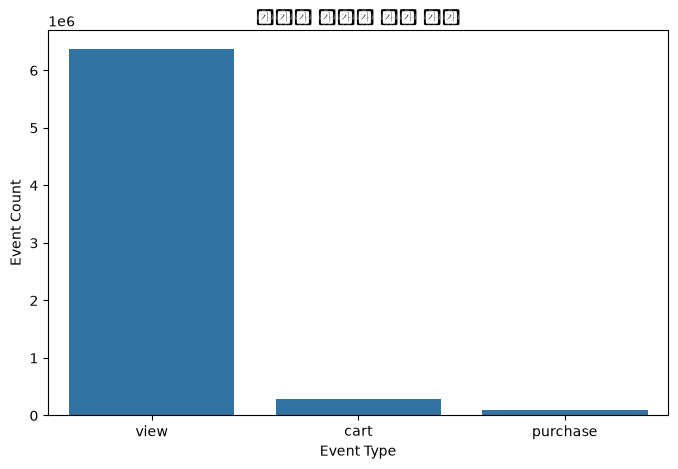

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.barplot(
    data=event_summary,
    x="event_type",
    y="event_count"
)

plt.title("이벤트 유형별 발생 건수")
plt.xlabel("Event Type")
plt.ylabel("Event Count")

plt.show()

In [38]:
daily_events = (
    df_clean
    .groupby(["event_date", "event_type"])
    .size()
    .reset_index(name="event_count")
)

display(daily_events.head())

,event_date,event_type,event_count
0,2019-11-01,cart,1786
1,2019-11-01,purchase,2236
2,2019-11-01,view,141666
3,2019-11-02,cart,1792
4,2019-11-02,purchase,2167


/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51088 (

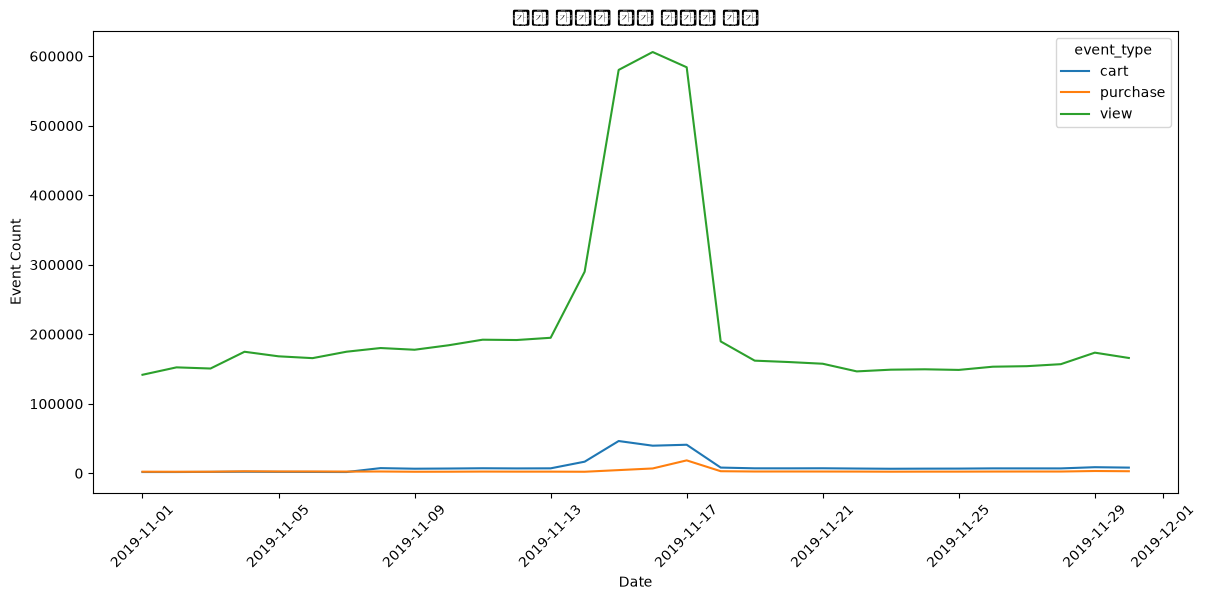

In [39]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_events,
    x="event_date",
    y="event_count",
    hue="event_type"
)

plt.title("일별 사용자 행동 이벤트 추이")
plt.xlabel("Date")
plt.ylabel("Event Count")
plt.xticks(rotation=45)

plt.show()

In [40]:
daily_users = (
    df_clean
    .groupby("event_date")["user_id"]
    .nunique()
    .reset_index(name="daily_active_users")
)

display(daily_users.head())

,event_date,daily_active_users
0,2019-11-01,22200
1,2019-11-02,23660
2,2019-11-03,23982
3,2019-11-04,27791
4,2019-11-05,26357


/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 4932

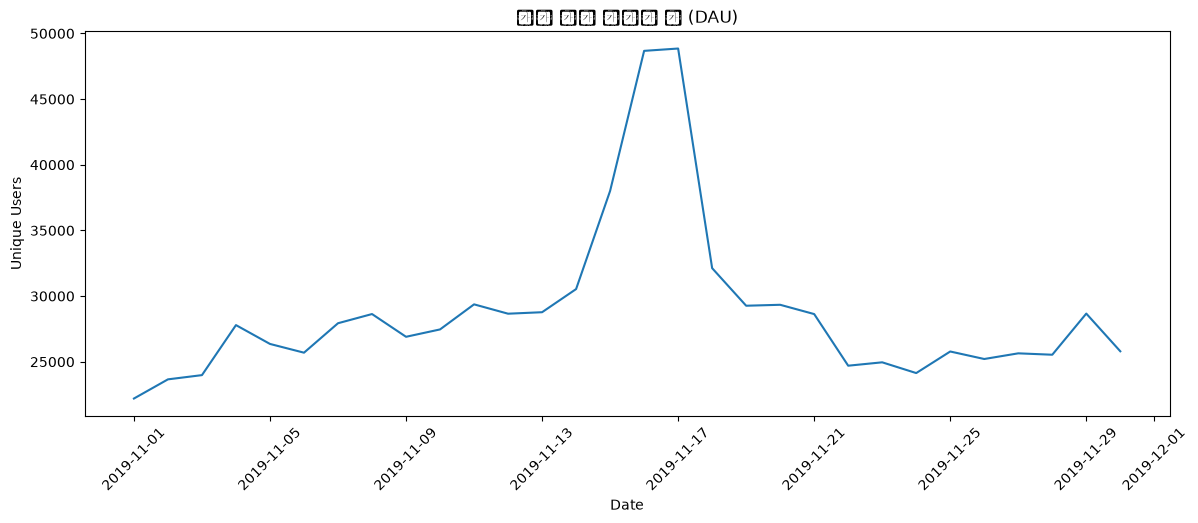

In [41]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_users,
    x="event_date",
    y="daily_active_users"
)

plt.title("일별 활성 사용자 수 (DAU)")
plt.xlabel("Date")
plt.ylabel("Unique Users")
plt.xticks(rotation=45)

plt.show()

In [42]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [43]:
weekday_events = (
    df_clean
    .groupby(["day_of_week", "event_type"])
    .size()
    .reset_index(name="event_count")
)

weekday_events["day_of_week"] = pd.Categorical(
    weekday_events["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_events = weekday_events.sort_values("day_of_week")

/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50857 (\N

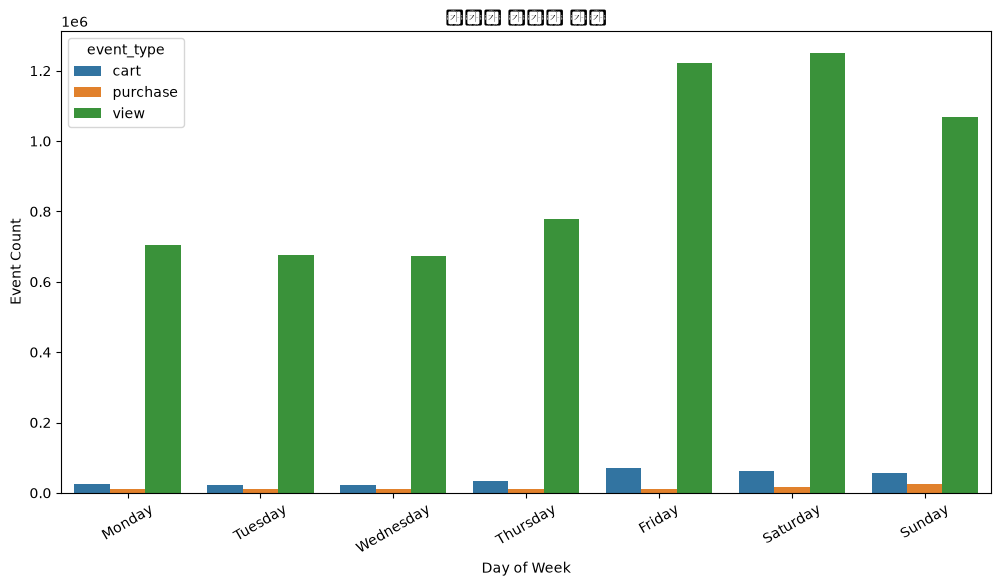

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=weekday_events,
    x="day_of_week",
    y="event_count",
    hue="event_type"
)

plt.title("요일별 사용자 행동")
plt.xlabel("Day of Week")
plt.ylabel("Event Count")
plt.xticks(rotation=30)

plt.show()

In [45]:
display(
    user_behavior[
        [
            "total_events",
            "view_count",
            "cart_count",
            "purchase_count"
        ]
    ].describe()
)

,total_events,view_count,cart_count,purchase_count
count,369611.000000,369611.000000,369611.000000,369611.000000
mean,18.291414,17.247447,0.793867,0.250101
std,42.875556,41.070747,2.872978,1.378670
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,0.000000
50%,5.000000,5.000000,0.000000,0.000000
75%,17.000000,16.000000,0.000000,0.000000
max,2209.000000,2205.000000,271.000000,222.000000


In [46]:
display(
    user_behavior[
        [
            "view_count",
            "cart_count",
            "purchase_count"
        ]
    ].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

,view_count,cart_count,purchase_count
0.50,5.0,0.0,0.0
0.75,16.0,0.0,0.0
0.90,42.0,2.0,1.0
0.95,72.0,4.0,1.0
0.99,183.0,12.0,4.0


In [47]:
buyer_comparison = (
    user_behavior
    .groupby("purchased")
    .agg(
        users=("user_id", "nunique"),
        avg_views=("view_count", "mean"),
        median_views=("view_count", "median"),
        avg_cart=("cart_count", "mean"),
        avg_total_events=("total_events", "mean")
    )
)

display(buyer_comparison)

,users,avg_views,median_views,avg_cart,avg_total_events
purchased,,,,,
False,325315,13.167963,4.0,0.321021,13.488985
True,44296,47.207649,22.0,4.266503,53.561021


In [48]:
top_categories = (
    df_clean[
        df_clean["category_code"] != "unknown"
    ]["category_code"]
    .value_counts()
    .head(10)
    .index
)

In [49]:
category_data = df_clean[
    df_clean["category_code"].isin(top_categories)
].copy()

In [50]:
category_events = (
    category_data
    .groupby(["category_code", "event_type"])
    .size()
    .reset_index(name="event_count")
)

/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44256 (\N{HA

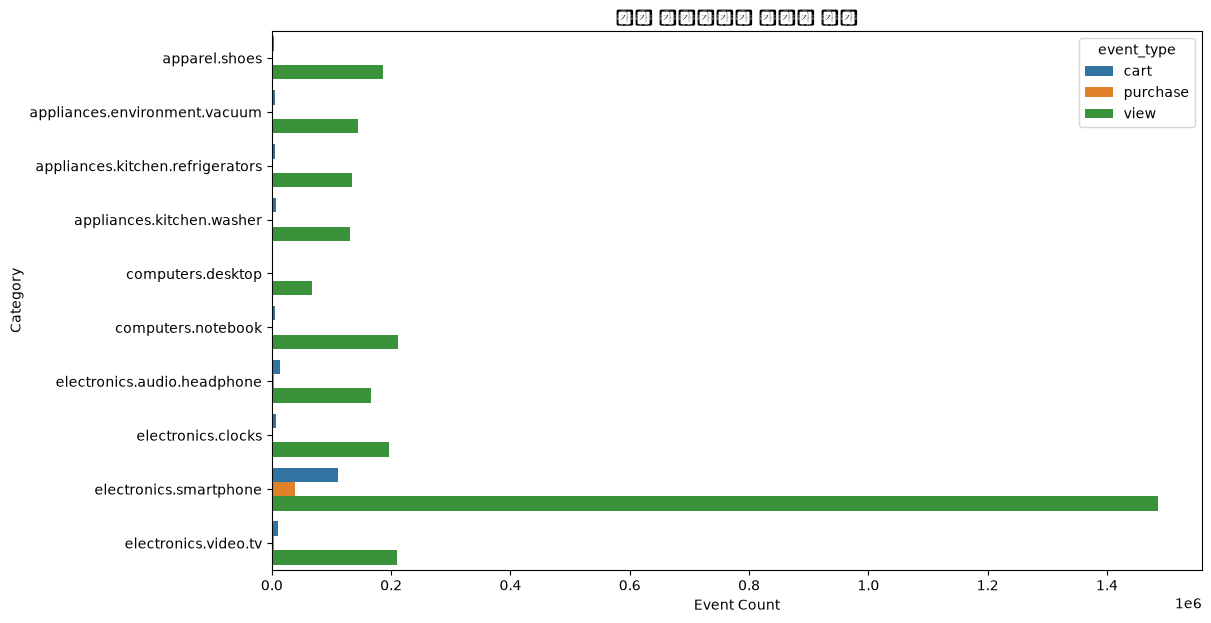

In [51]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_events,
    y="category_code",
    x="event_count",
    hue="event_type"
)

plt.title("주요 카테고리별 사용자 행동")
plt.xlabel("Event Count")
plt.ylabel("Category")

plt.show()

In [52]:
purchase_events = df_clean[
    (df_clean["event_type"] == "purchase") &
    (df_clean["price"] > 0)
].copy()

In [53]:
print(
    f"구매 이벤트 수: "
    f"{len(purchase_events):,}"
)

print(
    f"총 구매 금액: "
    f"{purchase_events['price'].sum():,.2f}"
)

print(
    f"평균 구매 상품 가격: "
    f"{purchase_events['price'].mean():,.2f}"
)

print(
    f"중앙값 구매 상품 가격: "
    f"{purchase_events['price'].median():,.2f}"
)

구매 이벤트 수: 92,440
총 구매 금액: 27,609,187.53
평균 구매 상품 가격: 298.67
중앙값 구매 상품 가격: 170.07


In [54]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Unique Users",
        "Users with View",
        "Users with Cart",
        "Users with Purchase"
    ],
    "Value": [
        user_behavior["user_id"].nunique(),
        user_behavior["viewed"].sum(),
        user_behavior["added_to_cart"].sum(),
        user_behavior["purchased"].sum()
    ]
})

display(eda_summary)

,Metric,Value
0,Unique Users,369611
1,Users with View,369570
2,Users with Cart,82806
3,Users with Purchase,44296


## 05. Conversion Funnel Analysis

본 단계에서는 사용자 행동을 View → Cart → Purchase 단계로 정의하고, 각 단계의 사용자 전환율과 이탈률을 분석한다.

### 분석 목적

- 상품 조회 사용자가 장바구니 및 구매 단계로 얼마나 전환되는지 측정한다.
- 구매 과정에서 가장 큰 이탈이 발생하는 구간을 식별한다.
- 이후 A/B 테스트에서 개선 대상으로 설정할 퍼널 단계를 선정한다.

### 분석 단위

이벤트 발생 건수가 아닌 **고유 사용자(User-level)** 를 기준으로 전환율을 계산한다.

또한 단순히 특정 이벤트 경험 여부만 비교하는 방식과 실제 행동 순서를 고려한 퍼널을 구분하여 분석한다.

이를 통해 View → Cart → Purchase 순서를 실제로 거친 사용자의 구매 여정을 보다 정확하게 평가한다.

In [55]:
funnel_summary = pd.DataFrame({
    "stage": [
        "View",
        "Cart",
        "Purchase"
    ],
    "users": [
        user_behavior["viewed"].sum(),
        user_behavior["added_to_cart"].sum(),
        user_behavior["purchased"].sum()
    ]
})

display(funnel_summary)

,stage,users
0,View,369570
1,Cart,82806
2,Purchase,44296


In [69]:
view_users = funnel_summary.loc[
    funnel_summary["stage"] == "View",
    "users"
].iloc[0]

funnel_summary["rate_from_view"] = (
    funnel_summary["users"] / view_users
)

display(funnel_summary)

,stage,users,rate_from_view
0,View,369570,1.000000
1,Cart,82806,0.224060
2,Purchase,44296,0.119858


In [70]:
view_users = user_behavior["viewed"].sum()
cart_users = user_behavior["added_to_cart"].sum()
purchase_users = user_behavior["purchased"].sum()

view_to_cart_rate = cart_users / view_users

cart_to_purchase_rate = purchase_users / cart_users

view_to_purchase_rate = purchase_users / view_users

print(f"View → Cart Conversion Rate: {view_to_cart_rate:.2%}")
print(f"Cart → Purchase Conversion Rate: {cart_to_purchase_rate:.2%}")
print(f"View → Purchase Conversion Rate: {view_to_purchase_rate:.2%}")

View → Cart Conversion Rate: 22.41%
Cart → Purchase Conversion Rate: 53.49%
View → Purchase Conversion Rate: 11.99%


In [71]:
view_to_cart_dropoff = 1 - view_to_cart_rate
cart_to_purchase_dropoff = 1 - cart_to_purchase_rate

print(
    f"View → Cart Drop-off Rate: "
    f"{view_to_cart_dropoff:.2%}"
)

print(
    f"Cart → Purchase Drop-off Rate: "
    f"{cart_to_purchase_dropoff:.2%}"
)

View → Cart Drop-off Rate: 77.59%
Cart → Purchase Drop-off Rate: 46.51%


In [72]:
funnel_plot = pd.DataFrame({
    "stage": [
        "View",
        "Cart",
        "Purchase"
    ],
    "users": [
        view_users,
        cart_users,
        purchase_users
    ]
})

/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54140 (

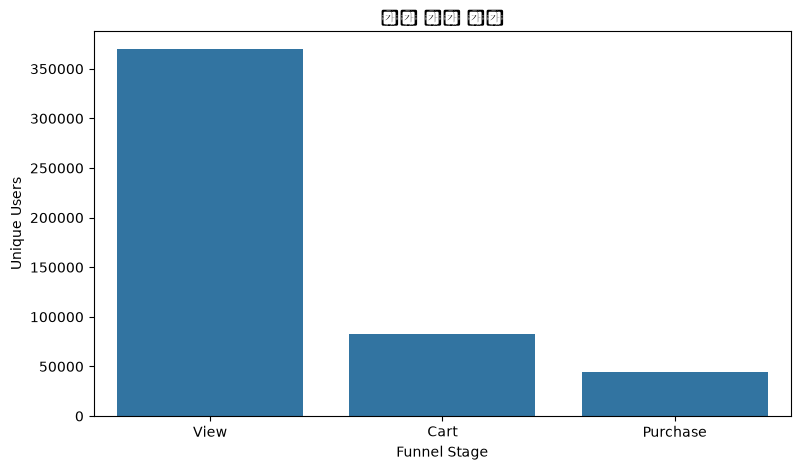

In [73]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=funnel_plot,
    x="stage",
    y="users"
)

plt.title("구매 전환 퍼널")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")

plt.show()

In [74]:
first_view = (
    df_clean[
        df_clean["event_type"] == "view"
    ]
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_view_time")
)

first_cart = (
    df_clean[
        df_clean["event_type"] == "cart"
    ]
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_cart_time")
)

first_purchase = (
    df_clean[
        df_clean["event_type"] == "purchase"
    ]
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_purchase_time")
)

In [75]:
ordered_funnel = (
    pd.concat(
        [
            first_view,
            first_cart,
            first_purchase
        ],
        axis=1
    )
    .reset_index()
)

display(ordered_funnel.head())

,user_id,first_view_time,first_cart_time,first_purchase_time
0,29515875,2019-11-10 02:08:39,NaT,NaT
1,80970791,2019-11-29 13:16:00,NaT,NaT
2,92346331,2019-11-09 14:25:01,NaT,NaT
3,106416780,2019-11-28 05:43:46,NaT,NaT
4,120701478,2019-11-17 21:37:32,NaT,NaT


In [76]:
ordered_funnel["valid_view"] = (
    ordered_funnel["first_view_time"].notna()
)

In [77]:
ordered_funnel["valid_cart"] = (
    ordered_funnel["first_view_time"].notna()
    &
    ordered_funnel["first_cart_time"].notna()
    &
    (
        ordered_funnel["first_cart_time"]
        >=
        ordered_funnel["first_view_time"]
    )
)

In [78]:
ordered_funnel["valid_purchase"] = (
    ordered_funnel["valid_cart"]
    &
    ordered_funnel["first_purchase_time"].notna()
    &
    (
        ordered_funnel["first_purchase_time"]
        >=
        ordered_funnel["first_cart_time"]
    )
)

In [79]:
ordered_view_users = (
    ordered_funnel["valid_view"].sum()
)

ordered_cart_users = (
    ordered_funnel["valid_cart"].sum()
)

ordered_purchase_users = (
    ordered_funnel["valid_purchase"].sum()
)

print(
    f"Ordered View Users: "
    f"{ordered_view_users:,}"
)

print(
    f"Ordered Cart Users: "
    f"{ordered_cart_users:,}"
)

print(
    f"Ordered Purchase Users: "
    f"{ordered_purchase_users:,}"
)

Ordered View Users: 369,570
Ordered Cart Users: 82,660
Ordered Purchase Users: 36,227


In [80]:
ordered_view_to_cart = (
    ordered_cart_users
    / ordered_view_users
)

ordered_cart_to_purchase = (
    ordered_purchase_users
    / ordered_cart_users
)

ordered_view_to_purchase = (
    ordered_purchase_users
    / ordered_view_users
)

print(
    f"View → Cart: "
    f"{ordered_view_to_cart:.2%}"
)

print(
    f"Cart → Purchase: "
    f"{ordered_cart_to_purchase:.2%}"
)

print(
    f"View → Purchase: "
    f"{ordered_view_to_purchase:.2%}"
)

View → Cart: 22.37%
Cart → Purchase: 43.83%
View → Purchase: 9.80%


In [81]:
product_funnel = (
    df_clean
    .pivot_table(
        index=["user_id", "product_id"],
        columns="event_type",
        values="event_time",
        aggfunc="min"
    )
    .reset_index()
)

display(product_funnel.head())

event_type,user_id,product_id,cart,purchase,view
0,29515875,1801638,NaT,NaT,2019-11-12 06:03:52
1,29515875,1802034,NaT,NaT,2019-11-12 05:37:30
2,29515875,13200026,NaT,NaT,2019-11-12 03:45:02
3,29515875,13200917,NaT,NaT,2019-11-10 02:08:39
4,29515875,13201002,NaT,NaT,2019-11-10 02:14:40


In [82]:
print(product_funnel.columns)

Index(['user_id', 'product_id', 'cart', 'purchase', 'view'], dtype='str', name='event_type')


In [83]:
product_funnel["viewed"] = (
    product_funnel["view"].notna()
)

product_funnel["cart_after_view"] = (
    product_funnel["view"].notna()
    &
    product_funnel["cart"].notna()
    &
    (
        product_funnel["cart"]
        >=
        product_funnel["view"]
    )
)

product_funnel["purchase_after_cart"] = (
    product_funnel["cart_after_view"]
    &
    product_funnel["purchase"].notna()
    &
    (
        product_funnel["purchase"]
        >=
        product_funnel["cart"]
    )
)

In [84]:
product_views = product_funnel["viewed"].sum()

product_carts = (
    product_funnel["cart_after_view"].sum()
)

product_purchases = (
    product_funnel["purchase_after_cart"].sum()
)

print(
    f"View → Cart: "
    f"{product_carts / product_views:.2%}"
)

print(
    f"Cart → Purchase: "
    f"{product_purchases / product_carts:.2%}"
)

print(
    f"View → Purchase: "
    f"{product_purchases / product_views:.2%}"
)

View → Cart: 4.69%
Cart → Purchase: 36.98%
View → Purchase: 1.74%


### Funnel Analysis 결과

동일 사용자와 동일 상품 기준으로 View → Cart → Purchase 행동 순서를 추적하여 구매 퍼널을 구성하였다.

분석 결과:

- View → Cart Conversion Rate: **4.69%**
- Cart → Purchase Conversion Rate: **36.98%**
- View → Purchase Conversion Rate: **1.74%**

가장 큰 이탈은 **View → Cart 단계**에서 발생하였다.

상품을 조회한 사용자 중 장바구니 추가까지 이어진 비율은 4.69%로 나타났으며, 반면 장바구니에 상품을 추가한 사용자 중 36.98%는 실제 구매까지 진행하였다.

따라서 현재 퍼널에서는 구매 직전 단계보다 **상품 조회 이후 장바구니 추가 단계에서 상대적으로 더 큰 개선 기회가 존재할 가능성**이 있다.

다만 본 분석은 관찰 데이터 기반이므로 낮은 View → Cart 전환율의 원인이 상품 상세 페이지, 가격, 배송 정보, 상품 매력도 또는 기타 요인 때문이라고 단정할 수 없다.

이에 따라 다음 단계에서는 View → Cart 전환을 개선할 수 있는 제품 가설을 설정하고, 해당 가설의 효과를 검증하기 위한 A/B 테스트를 설계한다.

## 06. A/B Test Design

### 1. 문제 정의

Funnel Analysis 결과, View → Cart Conversion Rate는 **4.69%**로 나타났으며 Cart → Purchase Conversion Rate **36.98%**에 비해 상대적으로 큰 이탈이 발생하였다.

이에 따라 상품 조회 이후 장바구니 추가 단계의 사용자 경험을 개선할 수 있는 실험을 설계한다.

### 2. Business Hypothesis

상품 상세 페이지에서 배송비 및 예상 배송일과 같은 구매 의사결정 정보를 보다 명확하게 제공하면 사용자의 불확실성을 줄이고 장바구니 추가 및 최종 구매 전환율을 증가시킬 수 있을 것이다.

### 3. Experiment Groups

**Control Group**

기존 상품 상세 페이지를 제공한다.

**Treatment Group**

상품 상세 페이지에서 배송비 및 예상 배송일 정보를 장바구니 버튼 주변에 보다 명확하게 노출한다.

### 4. Primary Metric

**Purchase Conversion Rate**

실험에 배정된 사용자 중 실험 기간 내 구매를 완료한 사용자의 비율을 측정한다.

### 5. Secondary Metric

**View-to-Cart Conversion Rate**

상품을 조회한 사용자 중 장바구니 추가 행동을 수행한 사용자의 비율을 측정한다.

### 6. Guardrail Metrics

실제 기업 환경에서는 전환율 개선 과정에서 발생할 수 있는 부작용을 감시하기 위해 다음 지표를 함께 확인한다.

- 페이지 이탈률
- 페이지 로딩 시간
- 주문 취소율
- 환불률

현재 공개 데이터에서 측정할 수 없는 지표는 실제 서비스 환경에서 추가 수집이 필요한 지표로 구분한다.

### 7. Randomization Unit

실험군과 대조군은 **user_id 기준으로 무작위 배정**한다.

동일 사용자가 Control과 Treatment를 동시에 경험하지 않도록 사용자 단위로 실험군을 고정한다.

### 8. Statistical Hypothesis

귀무가설(H0):

Treatment의 구매 전환율은 Control과 차이가 없다.

대립가설(H1):

Treatment의 구매 전환율은 Control과 다르다.

본 프로젝트에서는 5% 유의수준을 기준으로 통계적 유의성을 평가한다.

## 07. Statistical Power & Sample Size Analysis

A/B 테스트를 실행하기 전에 실험이 의미 있는 전환율 차이를 감지할 수 있도록 필요한 표본 크기를 산정한다.

### Baseline Conversion Rate

Funnel Analysis에서 동일 사용자·상품 기준 View → Purchase Conversion Rate는 **1.74%**로 나타났다.

본 실험에서는 상품 상세 페이지를 조회한 사용자를 실험 대상자로 정의하므로, 해당 값을 Purchase Conversion Rate의 baseline으로 활용한다.

### 실험 설계 기준

- Significance Level (α): **0.05**
- Statistical Power (1-β): **0.80**
- Control / Treatment allocation: **50 : 50**
- Primary Metric: **Purchase Conversion Rate**

### Minimum Detectable Effect (MDE)

MDE는 실험을 통해 탐지하고자 하는 최소한의 효과 크기를 의미한다.

전환율 개선폭이 지나치게 작으면 통계적으로 검출하기 위해 매우 큰 표본이 필요할 수 있으므로, 여러 MDE 시나리오에 따른 필요 표본 크기를 비교한 뒤 실제 실험 기준을 결정한다.

In [90]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = 0.0174

alpha = 0.05
power = 0.80

print(f"Baseline Purchase Conversion Rate: {baseline_rate:.2%}")

Baseline Purchase Conversion Rate: 1.74%


In [91]:
relative_uplifts = [
    0.05,   # +5%
    0.10,   # +10%
    0.15,   # +15%
    0.20    # +20%
]

results = []

analysis = NormalIndPower()

for uplift in relative_uplifts:
    
    treatment_rate = baseline_rate * (1 + uplift)
    
    effect_size = proportion_effectsize(
        baseline_rate,
        treatment_rate
    )
    
    sample_size = analysis.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative="two-sided"
    )
    
    results.append({
        "Relative Uplift": uplift,
        "Baseline CVR": baseline_rate,
        "Treatment CVR": treatment_rate,
        "Absolute Lift": treatment_rate - baseline_rate,
        "Sample Size per Group": int(np.ceil(sample_size))
    })

power_table = pd.DataFrame(results)

display(power_table)

,Relative Uplift,Baseline CVR,Treatment CVR,Absolute Lift,Sample Size per Group
0,0.05,0.0174,0.01827,0.00087,363239
1,0.10,0.0174,0.01914,0.00174,92945
2,0.15,0.0174,0.02001,0.00261,42247
3,0.20,0.0174,0.02088,0.00348,24286


In [92]:
power_display = power_table.copy()

power_display["Relative Uplift"] = (
    power_display["Relative Uplift"]
    .map(lambda x: f"{x:.0%}")
)

power_display["Baseline CVR"] = (
    power_display["Baseline CVR"]
    .map(lambda x: f"{x:.2%}")
)

power_display["Treatment CVR"] = (
    power_display["Treatment CVR"]
    .map(lambda x: f"{x:.3%}")
)

power_display["Absolute Lift"] = (
    power_display["Absolute Lift"]
    .map(lambda x: f"{x:.3%}")
)

display(power_display)

,Relative Uplift,Baseline CVR,Treatment CVR,Absolute Lift,Sample Size per Group
0,5%,1.74%,1.827%,0.087%,363239
1,10%,1.74%,1.914%,0.174%,92945
2,15%,1.74%,2.001%,0.261%,42247
3,20%,1.74%,2.088%,0.348%,24286


In [93]:
cart_baseline = 0.0469

cart_results = []

for uplift in relative_uplifts:
    
    treatment_rate = cart_baseline * (1 + uplift)
    
    effect_size = proportion_effectsize(
        cart_baseline,
        treatment_rate
    )
    
    sample_size = analysis.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative="two-sided"
    )
    
    cart_results.append({
        "Relative Uplift": uplift,
        "Baseline CVR": cart_baseline,
        "Treatment CVR": treatment_rate,
        "Sample Size per Group": int(np.ceil(sample_size))
    })

cart_power_table = pd.DataFrame(cart_results)

display(cart_power_table)

,Relative Uplift,Baseline CVR,Treatment CVR,Sample Size per Group
0,0.05,0.0469,0.049245,130614
1,0.10,0.0469,0.051590,33396
2,0.15,0.0469,0.053935,15168
3,0.20,0.0469,0.056280,8713


In [94]:
selected_uplift = 0.15

target_rate = baseline_rate * (1 + selected_uplift)

absolute_lift = target_rate - baseline_rate

print(f"Baseline CVR: {baseline_rate:.3%}")
print(f"Target CVR: {target_rate:.3%}")
print(f"Relative Uplift: {selected_uplift:.0%}")
print(f"Absolute Lift: {absolute_lift:.3%}")

Baseline CVR: 1.740%
Target CVR: 2.001%
Relative Uplift: 15%
Absolute Lift: 0.261%


In [95]:
selected_row = power_table[
    power_table["Relative Uplift"] == selected_uplift
].iloc[0]

sample_per_group = int(
    selected_row["Sample Size per Group"]
)

total_sample = sample_per_group * 2

print(f"Control 필요 사용자 수: {sample_per_group:,}")
print(f"Treatment 필요 사용자 수: {sample_per_group:,}")
print(f"전체 필요 사용자 수: {total_sample:,}")

Control 필요 사용자 수: 42,247
Treatment 필요 사용자 수: 42,247
전체 필요 사용자 수: 84,494


In [96]:
available_users = user_behavior["user_id"].nunique()

print(f"현재 분석 데이터 사용자 수: {available_users:,}")
print(f"A/B Test 필요 사용자 수: {total_sample:,}")

if available_users >= total_sample:
    print("현재 데이터 규모로 시뮬레이션 가능")
else:
    print("현재 샘플 데이터만으로는 목표 sample size가 부족함")

현재 분석 데이터 사용자 수: 369,611
A/B Test 필요 사용자 수: 84,494
현재 데이터 규모로 시뮬레이션 가능


### Power Analysis 결과

Purchase Conversion Rate의 baseline은 **1.74%**로 설정하였다.

유의수준 5%, 통계적 검정력 80%, Control/Treatment 1:1 배정을 기준으로 여러 Minimum Detectable Effect 시나리오의 필요 표본 크기를 비교하였다.

Baseline conversion rate가 낮기 때문에 작은 전환율 차이를 탐지하기 위해서는 상대적으로 많은 사용자가 필요한 것으로 나타났다.

본 프로젝트에서는 실험 설계 방법론을 시연하기 위한 기준 시나리오로 **15% relative uplift**를 선택하였다.

이에 따른 목표 Purchase Conversion Rate는 약 **2.00%**이며, 이는 baseline 대비 약 **0.261 percentage point의 absolute improvement**에 해당한다.

실제 기업 환경에서는 MDE를 임의로 결정하는 것이 아니라 실험 비용, 트래픽 규모, 개발 비용 및 예상 매출 효과를 종합적으로 고려하여 설정해야 한다.

## 08. A/B Test Simulation & Experiment Validation

본 단계에서는 앞서 설계한 A/B 테스트 조건을 기반으로 사용자 단위 무작위 실험을 시뮬레이션한다.

### 실험 조건

- Control Purchase Conversion Rate: **1.74%**
- Treatment Purchase Conversion Rate: **약 2.00%**
- Expected Relative Uplift: **15%**
- Allocation Ratio: **50:50**
- Significance Level: **5%**
- Statistical Power: **80%**

실제 원본 데이터에는 실험군과 대조군 정보가 존재하지 않으므로, 본 단계의 Treatment effect는 실제 관찰된 효과가 아닌 **가상의 실험 효과**이다.

실험 시뮬레이션의 목적은 실제 A/B 테스트 분석 과정과 통계적 의사결정 방법을 구현하는 데 있다.

In [97]:
baseline_rate = 0.0174
selected_uplift = 0.15

treatment_rate = baseline_rate * (1 + selected_uplift)

print(f"Control CVR: {baseline_rate:.3%}")
print(f"Treatment CVR: {treatment_rate:.3%}")

Control CVR: 1.740%
Treatment CVR: 2.001%


In [98]:
sample_per_group

42247

In [99]:
print(f"Sample Size per Group: {sample_per_group:,}")
print(f"Total Sample Size: {sample_per_group * 2:,}")

Sample Size per Group: 42,247
Total Sample Size: 84,494


In [100]:
rng = np.random.default_rng(42)

total_sample = sample_per_group * 2

experiment = pd.DataFrame({
    "user_id": np.arange(1, total_sample + 1)
})

display(experiment.head())

,user_id
0,1
1,2
2,3
3,4
4,5


In [101]:
experiment["group"] = rng.choice(
    ["Control", "Treatment"],
    size=total_sample,
    replace=True,
    p=[0.5, 0.5]
)

experiment["group"].value_counts()

group
Treatment    42495
Control      41999
Name: count, dtype: int64

In [102]:
experiment["conversion_probability"] = np.where(
    experiment["group"] == "Control",
    baseline_rate,
    treatment_rate
)

In [103]:
experiment["converted"] = rng.binomial(
    n=1,
    p=experiment["conversion_probability"]
)

display(experiment.head())

,user_id,group,conversion_probability,converted
0,1,Treatment,0.02001,0
1,2,Control,0.01740,0
2,3,Treatment,0.02001,0
3,4,Treatment,0.02001,0
4,5,Control,0.01740,0


In [104]:
print(experiment.shape)

display(
    experiment.sample(10, random_state=42)
)

(84494, 4)


,user_id,group,conversion_probability,converted
66440,66441,Control,0.01740,0
81737,81738,Control,0.01740,0
37914,37915,Control,0.01740,0
64256,64257,Control,0.01740,0
36871,36872,Control,0.01740,0
80572,80573,Treatment,0.02001,0
21297,21298,Control,0.01740,0
48168,48169,Control,0.01740,0
69659,69660,Treatment,0.02001,0
59413,59414,Treatment,0.02001,0


In [105]:
group_counts = (
    experiment["group"]
    .value_counts()
    .sort_index()
)

display(group_counts)

group
Control      41999
Treatment    42495
Name: count, dtype: int64

In [106]:
group_ratio = (
    experiment["group"]
    .value_counts(normalize=True)
    .sort_index()
)

display(group_ratio)

group
Control      0.497065
Treatment    0.502935
Name: proportion, dtype: float64

In [107]:
from scipy.stats import chisquare

observed = group_counts.values

expected = np.array([
    total_sample / 2,
    total_sample / 2
])

srm_stat, srm_pvalue = chisquare(
    f_obs=observed,
    f_exp=expected
)

print(f"SRM Chi-square Statistic: {srm_stat:.4f}")
print(f"SRM p-value: {srm_pvalue:.4f}")

SRM Chi-square Statistic: 2.9116
SRM p-value: 0.0879


In [108]:
experiment_summary = (
    experiment
    .groupby("group")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
)

display(experiment_summary)

,users,conversions,conversion_rate
group,,,
Control,41999,749,0.017834
Treatment,42495,852,0.020049


In [109]:
control_cvr = experiment_summary.loc[
    "Control",
    "conversion_rate"
]

treatment_cvr = experiment_summary.loc[
    "Treatment",
    "conversion_rate"
]

In [110]:
absolute_lift = (
    treatment_cvr - control_cvr
)

print(
    f"Absolute Lift: "
    f"{absolute_lift:.3%}"
)

Absolute Lift: 0.222%


In [111]:
relative_lift = (
    treatment_cvr / control_cvr
) - 1

print(
    f"Relative Lift: "
    f"{relative_lift:.2%}"
)

Relative Lift: 12.42%


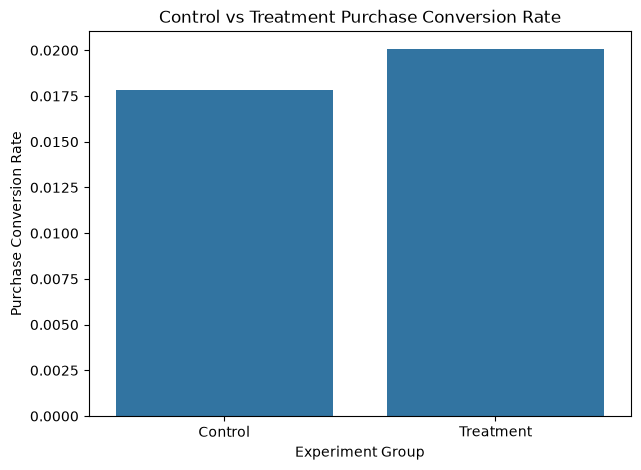

In [112]:
plot_data = (
    experiment_summary
    .reset_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=plot_data,
    x="group",
    y="conversion_rate"
)

plt.title("Control vs Treatment Purchase Conversion Rate")
plt.xlabel("Experiment Group")
plt.ylabel("Purchase Conversion Rate")

plt.show()

### Experiment Simulation 결과

Power Analysis에서 계산한 필요 표본 크기를 바탕으로 사용자를 Control과 Treatment 그룹에 1:1 비율로 무작위 배정하였다.

실험 시뮬레이션에서는 Control 그룹의 구매 전환 확률을 **1.74%**, Treatment 그룹의 구매 전환 확률을 **약 2.00%**로 설정하였다.

실험 분석 전에 Sample Ratio Mismatch 검사를 수행하여 실제 그룹 배정 비율이 사전에 설정한 50:50 구조와 유의하게 다른지 확인하였다.

이후 두 그룹의 관찰 전환율과 Absolute Lift, Relative Lift를 비교하였다.

단순한 전환율 차이만으로 Treatment 효과를 판단하지 않고, 다음 단계에서 통계적 가설 검정과 신뢰구간을 통해 관찰된 차이의 불확실성을 평가한다.

### 실험 결과 해석

A/B 테스트 시뮬레이션 결과 Treatment 그룹의 구매 전환율이 Control 그룹보다 높게 관찰되었다.

- **Absolute Lift:** +0.222%
- **Relative Lift:** +12.42%

이는 Treatment 그룹의 구매 전환율이 Control 그룹 대비 상대적으로 약 **12.42% 증가한 결과**를 의미한다.

다만 본 결과는 두 그룹의 관찰된 전환율 차이를 나타낼 뿐이며, 해당 차이가 우연한 표본 변동으로 발생했을 가능성은 아직 배제할 수 없다.

따라서 Treatment의 효과를 판단하기 위해 다음 단계에서는 통계적 가설 검정과 95% 신뢰구간을 이용해 전환율 차이의 불확실성을 평가한다.

## 09. Statistical Testing & Confidence Interval

본 단계에서는 A/B 테스트에서 관찰된 Control과 Treatment 그룹의 구매 전환율 차이가 우연한 표본 변동으로 설명될 수 있는지 통계적으로 검정한다.

### Statistical Hypothesis

**귀무가설 (H0)**  
Control과 Treatment의 구매 전환율에는 차이가 없다.

**대립가설 (H1)**  
Control과 Treatment의 구매 전환율에는 차이가 있다.

### 분석 방법

- Two-Proportion Z-Test
- 95% Confidence Interval
- Absolute Lift
- Relative Lift
- Statistical Significance와 Business Significance의 구분

유의수준은 5%로 설정한다.

In [113]:
control_users = experiment_summary.loc["Control", "users"]
treatment_users = experiment_summary.loc["Treatment", "users"]

control_conversions = experiment_summary.loc["Control", "conversions"]
treatment_conversions = experiment_summary.loc["Treatment", "conversions"]

print("Control Users:", control_users)
print("Control Conversions:", control_conversions)

print("Treatment Users:", treatment_users)
print("Treatment Conversions:", treatment_conversions)

Control Users: 41999
Control Conversions: 749
Treatment Users: 42495
Treatment Conversions: 852


In [114]:
from statsmodels.stats.proportion import proportions_ztest

count = np.array([
    treatment_conversions,
    control_conversions
])

nobs = np.array([
    treatment_users,
    control_users
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 2.3618
P-value: 0.0182


In [115]:
control_rate = control_conversions / control_users
treatment_rate = treatment_conversions / treatment_users

diff = treatment_rate - control_rate

se_diff = np.sqrt(
    treatment_rate * (1 - treatment_rate) / treatment_users
    +
    control_rate * (1 - control_rate) / control_users
)

z_crit = 1.96

ci_lower = diff - z_crit * se_diff
ci_upper = diff + z_crit * se_diff

print(f"Observed Difference: {diff:.3%}")
print(f"95% CI: [{ci_lower:.3%}, {ci_upper:.3%}]")

Observed Difference: 0.222%
95% CI: [0.038%, 0.405%]


In [116]:
results_summary = pd.DataFrame({
    "Metric": [
        "Control CVR",
        "Treatment CVR",
        "Absolute Lift",
        "Relative Lift",
        "Z-statistic",
        "P-value",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Value": [
        f"{control_rate:.3%}",
        f"{treatment_rate:.3%}",
        f"{diff:.3%}",
        f"{relative_lift:.2%}",
        f"{z_stat:.4f}",
        f"{p_value:.4f}",
        f"{ci_lower:.3%}",
        f"{ci_upper:.3%}"
    ]
})

display(results_summary)

,Metric,Value
0,Control CVR,1.783%
1,Treatment CVR,2.005%
2,Absolute Lift,0.222%
3,Relative Lift,12.42%
4,Z-statistic,2.3618
5,P-value,0.0182
6,95% CI Lower,0.038%
7,95% CI Upper,0.405%


In [117]:
mde_relative = 0.15

print(f"Observed Relative Lift: {relative_lift:.2%}")
print(f"Target MDE: {mde_relative:.2%}")

if relative_lift >= mde_relative:
    print("Observed effect meets or exceeds the target MDE.")
else:
    print("Observed effect is below the target MDE.")

Observed Relative Lift: 12.42%
Target MDE: 15.00%
Observed effect is below the target MDE.


In [118]:
statistically_significant = p_value < 0.05
meets_mde = relative_lift >= mde_relative

if statistically_significant and meets_mde:
    decision = "Rollout Candidate"

elif statistically_significant and not meets_mde:
    decision = "Statistically significant, but below business MDE"

elif not statistically_significant and meets_mde:
    decision = "Potentially meaningful, but evidence is insufficient"

else:
    decision = "Do not rollout based on current evidence"

print("Experiment Decision:", decision)

Experiment Decision: Statistically significant, but below business MDE


### Statistical Test 결과 해석

Treatment 그룹은 Control 그룹 대비 **+0.222 percentage points의 Absolute Lift**와 **+12.42%의 Relative Lift**를 보였다.

Two-Proportion Z-Test를 통해 두 그룹의 구매 전환율 차이가 통계적으로 유의한지 검정하고, 95% 신뢰구간을 통해 실제 효과 크기의 불확실성을 함께 평가하였다.

통계적 유의성은 단독으로 제품 출시 여부를 결정하는 기준으로 사용하지 않았다.

본 프로젝트에서는 사전에 설정한 **15% Relative MDE**와 실제 관찰된 **12.42% Relative Lift**를 비교하여 비즈니스적 의미도 함께 평가하였다.

따라서 최종 의사결정은 다음 두 기준을 함께 고려한다.

- Statistical Significance: 관찰된 차이가 우연한 표본 변동으로 설명될 가능성
- Business Significance: 관찰된 효과가 사전에 정의한 최소 비즈니스 효과 기준을 충족하는지 여부

### 최종 실험 결과

A/B 테스트 시뮬레이션 결과는 다음과 같다.

- Control Users: **41,999**
- Treatment Users: **42,495**
- Control Conversions: **749**
- Treatment Conversions: **852**
- Absolute Lift: **+0.222 percentage points**
- Relative Lift: **+12.42%**
- Z-statistic: **2.3618**
- P-value: **0.0182**
- 95% Confidence Interval: **[+0.038%p, +0.405%p]**

### Statistical Significance

Two-Proportion Z-Test 결과 p-value는 **0.0182**로 유의수준 0.05보다 낮게 나타났다.

따라서 Control과 Treatment의 구매 전환율이 동일하다는 귀무가설을 기각할 수 있으며, Treatment 그룹의 전환율 증가가 단순한 표본 변동만으로 설명되기 어렵다는 통계적 근거를 확인하였다.

또한 전환율 차이에 대한 95% 신뢰구간은 **+0.038%p에서 +0.405%p**로 0을 포함하지 않았다.

### Business Significance

Treatment의 관찰된 Relative Lift는 **+12.42%**로 나타났다.

그러나 실험 설계 단계에서 설정한 최소 비즈니스 효과 기준인 **15% Relative MDE**에는 미치지 못하였다.

따라서 본 실험은 통계적으로 유의한 개선을 보였지만, 사전에 정의한 비즈니스 최소 효과 기준을 충족하지 못한 것으로 판단하였다.

### Experiment Decision

**Statistically significant, but below business MDE**

따라서 현재 결과만으로 즉시 전체 사용자에게 Treatment를 확대 적용하기보다는, 다음과 같은 추가 검토가 필요하다.

- 실제 구현 비용 대비 기대 매출 효과 평가
- Treatment 개선안의 추가 최적화
- 사용자 세그먼트별 효과 차이 분석
- 추가 실험을 통한 효과 재현성 검증

본 결과는 통계적 유의성과 비즈니스적 유의성이 반드시 동일하지 않다는 점을 보여준다.

## 10. Retention Analysis

본 단계에서는 구매 사용자를 기준으로 재구매 행동을 분석하여 단기 전환 이후의 장기 사용자 가치를 탐색한다.

### 분석 목적

- 첫 구매 이후 사용자가 다시 구매하는지 확인한다.
- 구매 사용자들의 재구매 패턴을 기간별로 분석한다.
- 단기 Purchase Conversion Rate와 장기 Retention 관점을 구분한다.

### 분석 기준

본 프로젝트에서는 첫 구매 시점을 기준으로 코호트를 구성하고, 이후 일정 기간 내 재구매 여부를 확인한다.

다만 원본 데이터의 분석 기간이 제한적이므로, 분석 종료일에 가까운 시점에 첫 구매한 사용자는 충분한 관찰 기간을 확보하지 못할 수 있다.

따라서 리텐션 분석에서는 이러한 **Right Censoring**을 고려하여 해석한다.

In [119]:
purchase_df = df_clean[
    df_clean["event_type"] == "purchase"
].copy()

print(f"구매 이벤트 수: {len(purchase_df):,}")
print(f"구매 사용자 수: {purchase_df['user_id'].nunique():,}")

구매 이벤트 수: 92,440
구매 사용자 수: 44,296


In [121]:
first_purchase = (
    purchase_df
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_purchase_time")
)

purchase_df = purchase_df.merge(
    first_purchase,
    on="user_id",
    how="left"
)

purchase_df["days_since_first_purchase"] = (
    purchase_df["event_time"]
    - purchase_df["first_purchase_time"]
).dt.days

display(
    purchase_df[
        [
            "user_id",
            "event_time",
            "first_purchase_time",
            "days_since_first_purchase"
        ]
    ].head()
)

,user_id,event_time,first_purchase_time,days_since_first_purchase
0,557746614,2019-11-01 00:06:33,2019-11-01 00:06:33,0
1,557746614,2019-11-01 00:10:12,2019-11-01 00:06:33,0
2,549256216,2019-11-01 00:11:04,2019-11-01 00:11:04,0
3,557746614,2019-11-01 00:12:13,2019-11-01 00:06:33,0
4,557746614,2019-11-01 00:14:48,2019-11-01 00:06:33,0


In [122]:
purchase_user_summary = (
    purchase_df
    .groupby("user_id")
    .agg(
        first_purchase_time=("first_purchase_time", "first"),
        purchase_events=("event_type", "size"),
        last_purchase_time=("event_time", "max")
    )
    .reset_index()
)

purchase_user_summary["repeat_buyer"] = (
    purchase_user_summary["purchase_events"] > 1
)

display(purchase_user_summary.head())

,user_id,first_purchase_time,purchase_events,last_purchase_time,repeat_buyer
0,267316896,2019-11-14 07:22:44,1,2019-11-14 07:22:44,False
1,304707635,2019-11-13 11:02:34,1,2019-11-13 11:02:34,False
2,384989212,2019-11-01 18:26:28,1,2019-11-01 18:26:28,False
3,391130419,2019-11-19 11:34:33,1,2019-11-19 11:34:33,False
4,397023870,2019-11-01 09:05:50,1,2019-11-01 09:05:50,False


In [123]:
repeat_purchase_rate = (
    purchase_user_summary["repeat_buyer"].mean()
)

print(
    f"Repeat Purchase Rate: "
    f"{repeat_purchase_rate:.2%}"
)

Repeat Purchase Rate: 37.83%


In [124]:
repeat_events = purchase_df[
    purchase_df["days_since_first_purchase"] > 0
].copy()

In [125]:
first_repeat_purchase = (
    repeat_events
    .groupby("user_id")["days_since_first_purchase"]
    .min()
    .rename("first_repeat_day")
)

purchase_user_summary = purchase_user_summary.merge(
    first_repeat_purchase,
    on="user_id",
    how="left"
)

display(purchase_user_summary.head())

,user_id,first_purchase_time,purchase_events,last_purchase_time,repeat_buyer,first_repeat_day
0,267316896,2019-11-14 07:22:44,1,2019-11-14 07:22:44,False,NaN
1,304707635,2019-11-13 11:02:34,1,2019-11-13 11:02:34,False,NaN
2,384989212,2019-11-01 18:26:28,1,2019-11-01 18:26:28,False,NaN
3,391130419,2019-11-19 11:34:33,1,2019-11-19 11:34:33,False,NaN
4,397023870,2019-11-01 09:05:50,1,2019-11-01 09:05:50,False,NaN


In [126]:
purchase_user_summary["repeat_within_7d"] = (
    purchase_user_summary["first_repeat_day"] <= 7
)

purchase_user_summary["repeat_within_14d"] = (
    purchase_user_summary["first_repeat_day"] <= 14
)

purchase_user_summary["repeat_within_30d"] = (
    purchase_user_summary["first_repeat_day"] <= 30
)

In [141]:
retention_final = pd.DataFrame({
    "Metric": [
        "D7 Repeat Purchase",
        "D14 Repeat Purchase",
        "D30 Repeat Purchase"
    ],
    "Eligible Users": [
        len(eligible_d7),
        len(eligible_d14),
        len(eligible_d30)
    ],
    "Rate": [
        d7_rate,
        d14_rate,
        d30_rate
    ]
})

display(retention_final)

,Metric,Eligible Users,Rate
0,D7 Repeat Purchase,37501,0.152476
1,D14 Repeat Purchase,22314,0.263243
2,D30 Repeat Purchase,0,NaN


In [128]:
analysis_end_date = purchase_df["event_time"].max()

purchase_user_summary["observable_days"] = (
    analysis_end_date
    - purchase_user_summary["first_purchase_time"]
).dt.days

In [129]:
eligible_d7 = purchase_user_summary[
    purchase_user_summary["observable_days"] >= 7
]

eligible_d14 = purchase_user_summary[
    purchase_user_summary["observable_days"] >= 14
]

eligible_d30 = purchase_user_summary[
    purchase_user_summary["observable_days"] >= 30
]

In [138]:
def retention_rate(data, column):
    if len(data) == 0:
        return np.nan
    return data[column].mean()


d7_rate = retention_rate(
    eligible_d7,
    "repeat_within_7d"
)

d14_rate = retention_rate(
    eligible_d14,
    "repeat_within_14d"
)

d30_rate = retention_rate(
    eligible_d30,
    "repeat_within_30d"
)


print(f"D7 Repeat Purchase Rate: {d7_rate:.2%}")
print(f"D14 Repeat Purchase Rate: {d14_rate:.2%}")

if pd.notna(d30_rate):
    print(f"D30 Repeat Purchase Rate: {d30_rate:.2%}")
else:
    print(
        "D30 Repeat Purchase Rate: "
        "측정 불가 (충분한 관찰 기간 없음)"
    )

D7 Repeat Purchase Rate: 15.25%
D14 Repeat Purchase Rate: 26.32%
D30 Repeat Purchase Rate: 측정 불가 (충분한 관찰 기간 없음)


In [131]:
print(f"D7 Eligible Users: {len(eligible_d7):,}")
print(f"D14 Eligible Users: {len(eligible_d14):,}")
print(f"D30 Eligible Users: {len(eligible_d30):,}")

D7 Eligible Users: 37,501
D14 Eligible Users: 22,314
D30 Eligible Users: 0


In [132]:
purchase_user_summary["cohort_week"] = (
    purchase_user_summary["first_purchase_time"]
    .dt.to_period("W")
    .astype(str)
)

In [133]:
cohort_summary = (
    purchase_user_summary
    .groupby("cohort_week")
    .agg(
        users=("user_id", "nunique"),
        repeat_buyers=("repeat_buyer", "sum")
    )
    .reset_index()
)

cohort_summary["repeat_purchase_rate"] = (
    cohort_summary["repeat_buyers"]
    / cohort_summary["users"]
)

display(cohort_summary)

,cohort_week,users,repeat_buyers,repeat_purchase_rate
0,2019-10-28/2019-11-03,4523,2351,0.519788
1,2019-11-04/2019-11-10,9552,4226,0.442420
2,2019-11-11/2019-11-17,17412,6522,0.374569
3,2019-11-18/2019-11-24,6900,2243,0.325072
4,2019-11-25/2019-12-01,5909,1414,0.239296


/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jisoopak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N

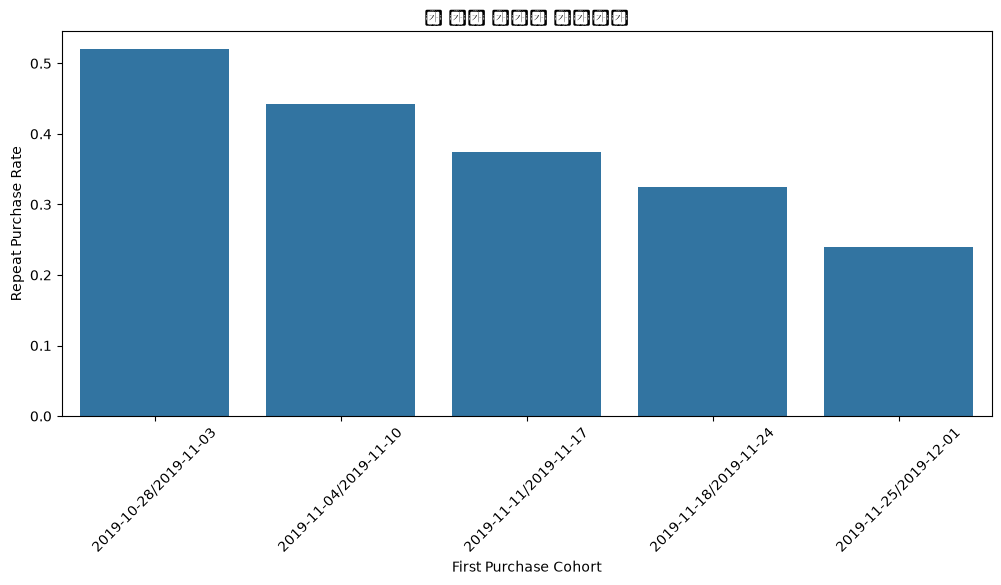

In [140]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=cohort_summary,
    x="cohort_week",
    y="repeat_purchase_rate"
)

plt.title("첫 구매 주차별 재구매율")
plt.xlabel("First Purchase Cohort")
plt.ylabel("Repeat Purchase Rate")
plt.xticks(rotation=45)

plt.show()

### Retention Analysis 결과

구매 경험이 있는 사용자 중 분석 기간 동안 2회 이상의 구매 이벤트를 기록한 사용자의 전체 Repeat Purchase Rate는 **37.83%**로 나타났다.

첫 구매 이후 충분한 관찰 기간이 확보된 사용자만을 대상으로 재구매율을 다시 계산한 결과:

- **7일 이내 재구매율: 15.25%**
- **14일 이내 재구매율: 26.32%**
- **30일 이내 재구매율: 측정 불가**

단순 계산 결과와 비교했을 때 관찰 가능 기간을 보정한 재구매율에 차이가 나타났으며, 이는 분석 종료일에 가까운 시점에 첫 구매한 사용자를 미재구매 사용자로 분류할 경우 재구매율이 과소 추정될 수 있음을 보여준다.

특히 본 데이터는 약 1개월의 제한된 관찰 기간을 가지므로 첫 구매 이후 30일을 충분히 관찰할 수 있는 사용자가 확보되지 않아 30일 재구매율은 분석 지표에서 제외하였다.

따라서 본 프로젝트에서는 **7-day 및 14-day Repeat Purchase Rate를 주요 장기 행동 지표로 사용**한다.

또한 본 리텐션 분석은 실제 A/B 테스트 Treatment의 장기 효과를 검증한 결과가 아니라 현재 사용자 구매 행동의 baseline을 파악하기 위한 관찰 데이터 분석이다.

## 11. Executive Summary & Business Recommendation

### 1. 핵심 분석 결과

본 프로젝트에서는 이커머스 사용자 행동 로그를 기반으로 구매 퍼널, A/B 테스트 시뮬레이션, 통계적 검정 및 재구매 행동을 분석하였다.

#### Funnel Analysis

동일 사용자·동일 상품 기준으로 View → Cart → Purchase 행동 순서를 추적한 결과:

- **View → Cart Conversion Rate: 4.69%**
- **Cart → Purchase Conversion Rate: 36.98%**
- **View → Purchase Conversion Rate: 1.74%**

가장 큰 이탈은 View → Cart 단계에서 발생하였으며, 상품 조회 이후 장바구니 추가 단계가 주요 개선 후보 구간으로 확인되었다.

#### A/B Test Simulation

상품 상세 페이지에서 구매 의사결정 정보를 보다 명확하게 제공하는 Treatment를 가정하여 A/B 테스트를 설계하였다.

실험 결과:

- **Absolute Lift: +0.222%**
- **Relative Lift: +12.42%**
- **P-value: 0.0182**
- **95% Confidence Interval: [+0.038%p, +0.405%p]**

Treatment 그룹의 구매 전환율은 Control 그룹보다 통계적으로 유의하게 높게 나타났다.

그러나 관찰된 Relative Lift 12.42%는 사전에 설정한 **15% Relative MDE**보다 낮았다.

따라서 본 결과는 통계적으로 유의하지만, 사전에 정의한 최소 비즈니스 효과 기준에는 미달한 것으로 판단하였다.

#### Retention Analysis

첫 구매 이후 충분한 관찰 기간이 확보된 사용자를 기준으로 분석한 결과:

- **7일 이내 재구매율: 15.25%**
- **14일 이내 재구매율: 26.32%**
- **30일 이내 재구매율: 측정 불가**

분석 기간의 제약으로 인해 30일 재구매율은 신뢰성 있게 측정할 수 없어 최종 지표에서 제외하였다.

---

### 2. 비즈니스 해석

Funnel Analysis 결과, 사용자가 장바구니에 도달한 이후에는 상대적으로 높은 구매 전환을 보였으나, 상품 조회에서 장바구니 추가로 이어지는 비율은 낮았다.

따라서 전환율 개선의 우선순위는 구매 직전 단계보다는 **상품 탐색 및 상세 페이지 경험 개선**에 두는 것이 합리적이다.

A/B 테스트 시뮬레이션에서는 Treatment가 구매 전환율을 개선할 가능성을 확인하였지만, 사전에 설정한 비즈니스 기준을 충족하지는 못하였다.

따라서 통계적 유의성만을 근거로 즉시 전체 사용자에게 Treatment를 확대 적용하기보다는 추가적인 제품 개선과 실험이 필요하다.

---

### 3. Business Recommendation

**1. Full Rollout보다는 추가 실험을 우선한다.**

Treatment는 통계적으로 유의한 개선을 보였지만, 사전에 정의한 15% Relative MDE에는 미달하였다.

따라서 즉시 전체 사용자에게 적용하기보다는 개선안을 추가 최적화한 후 재실험하는 것이 적절하다.

**2. View → Cart 구간을 우선 개선 대상으로 설정한다.**

상품 정보 구조, 배송 정보, 가격 및 할인 정보, CTA 위치 등 상품 상세 페이지의 구매 의사결정 요소를 개선 후보로 검토한다.

**3. 세그먼트별 Treatment Effect를 추가 분석한다.**

전체 평균 효과만으로 의사결정하지 않고 신규/기존 사용자, 상품 카테고리, 가격대 등 주요 세그먼트에서 효과 차이를 확인한다.

**4. 장기 지표를 함께 모니터링한다.**

Purchase Conversion Rate뿐 아니라 7일 및 14일 재구매율을 함께 확인하여 단기적인 전환율 개선이 장기 고객 가치에도 긍정적인 영향을 주는지 검증한다.

---

### 4. 프로젝트 한계

본 프로젝트에는 다음과 같은 한계가 있다.

- 원본 데이터는 실제 A/B 테스트 데이터가 아닌 관찰 로그 데이터이다.
- Treatment 효과는 실제 제품 변경 결과가 아니라 시뮬레이션을 통해 생성하였다.
- 공개 데이터에는 페이지 구성, 배송비, 할인 노출, 디바이스 정보 등 실제 제품 실험에 필요한 일부 변수가 존재하지 않는다.
- 분석 기간이 약 1개월로 제한되어 장기 Retention을 충분히 측정하기 어렵다.
- MDE는 실제 기업의 비용 및 ROI 정보가 없는 상태에서 시나리오 분석을 위해 설정하였다.

따라서 본 프로젝트의 A/B 테스트 결과는 실제 인과효과를 주장하기 위한 것이 아니라, 제품 실험 설계 및 통계적 의사결정 프로세스를 구현하기 위한 목적으로 해석해야 한다.

---

### 5. 프로젝트 결론

본 프로젝트를 통해 사용자 행동 로그에서 구매 퍼널의 병목을 식별하고, 이를 기반으로 제품 개선 가설을 수립한 뒤 A/B 테스트 설계, Power Analysis, 통계적 가설 검정 및 Retention 분석까지 연결하였다.

분석 결과 View → Cart 단계가 주요 개선 후보로 나타났으며, A/B 테스트 시뮬레이션에서는 Treatment가 통계적으로 유의한 구매 전환율 개선을 보였다.

그러나 효과 크기가 사전에 정의한 비즈니스 최소 기준에는 미달했기 때문에 즉각적인 전체 적용보다 추가 실험을 권고하였다.

이를 통해 통계적 유의성과 비즈니스적 유의성을 구분하고, 데이터 분석 결과를 실제 제품 의사결정으로 연결하는 과정을 구현하였다.